[1. 라이브러리 임포트 및 설정]

In [11]:
# ======================================================
# ODQA 데이터 EDA - Baseline 기준
# ======================================================

from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tqdm import tqdm
from collections import Counter

sns.set(style="whitegrid", font="NanumGothic", rc={"axes.unicode_minus": False})
plt.rcParams["figure.figsize"] = (8, 4)


[2. 데이터 로드]

In [9]:
import os
print(os.getcwd())

/data/ephemeral/git/pro-nlp-mrc-nlp-01


In [ ]:
print("데이터 로드 중...")

train_dataset = load_from_disk("./notebooks/data/train_dataset")
test_dataset = load_from_disk("./notebooks/data/test_dataset")

print(train_dataset)
print(test_dataset)

train_df = pd.DataFrame(train_dataset["train"])
val_df = pd.DataFrame(train_dataset["validation"])

print(f"Train 개수: {len(train_df)}, Validation 개수: {len(val_df)}")


데이터 로드 중...
DatasetDict({
    train: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 3952
    })
    validation: Dataset({
        features: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__'],
        num_rows: 240
    })
})
DatasetDict({
    validation: Dataset({
        features: ['question', 'id'],
        num_rows: 600
    })
})
Train 개수: 3952, Validation 개수: 240


[3. 데이터 구조 확인]

In [4]:
print("\n[샘플 예시]")
display(train_df.head(2))
print("\n컬럼:", train_df.columns.tolist())



[샘플 예시]


,title,context,question,id,answers,document_id,__index_level_0__
0,미국 상원,미국 상의원 또는 미국 상원(United States Senate)은 양원제인 미국...,대통령을 포함한 미국의 행정부 견제권을 갖는 국가 기관은?,mrc-1-000067,"{'answer_start': [235], 'text': ['하원']}",18293,42
1,인사조직관리,'근대적 경영학' 또는 '고전적 경영학'에서 현대적 경영학으로 전환되는 시기는 19...,현대적 인사조직관리의 시발점이 된 책은?,mrc-0-004397,"{'answer_start': [212], 'text': ['《경영의 실제》']}",51638,2873



컬럼: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__']


[4. 텍스트 길이 분석]


평균 길이:


context_len     920.220648
question_len     29.322368
answer_len        6.275051
dtype: float64

findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

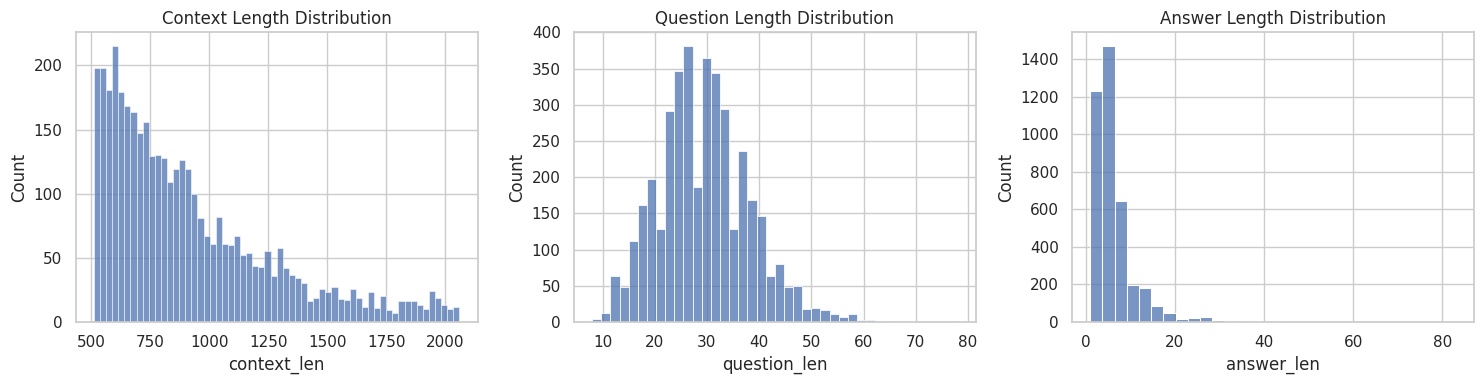

In [7]:
train_df["context_len"] = train_df["context"].apply(len)
train_df["question_len"] = train_df["question"].apply(len)
train_df["answer_len"] = train_df["answers"].apply(lambda x: len(x["text"][0]) if x["text"] else 0)

print("\n평균 길이:")
display(train_df[["context_len", "question_len", "answer_len"]].mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(train_df["context_len"], bins=60, ax=axes[0])
axes[0].set_title("Context Length Distribution")

sns.histplot(train_df["question_len"], bins=40, ax=axes[1])
axes[1].set_title("Question Length Distribution")

sns.histplot(train_df["answer_len"], bins=30, ax=axes[2])
axes[2].set_title("Answer Length Distribution")

plt.tight_layout()
plt.show()


[5. 질문 유형 분석]

In [ ]:
def classify_qtype(q):
    if q.startswith("무엇") or q.startswith("뭐"):
        return "무엇"
    elif q.startswith("누가") or q.startswith("누구"):
        return "누구"
    elif q.startswith("언제"):
        return "언제"
    elif q.startswith("어디"):
        return "어디"
    elif q.startswith("왜"):
        return "왜"
    elif q.startswith("어떻게"):
        return "어떻게"
    else:
        return "기타"

train_df["qtype"] = train_df["question"].apply(classify_qtype)

sns.countplot(data=train_df, x="qtype", order=train_df["qtype"].value_counts().index)
plt.title("질문 유형 분포")
plt.show()


[6. 중복 및 결측치 확인]

In [ ]:
print("중복 질문 개수:", train_df["question"].duplicated().sum())
print("결측 context:", train_df["context"].isnull().sum())


[7. Answer 위치 유효성 검사]

In [ ]:
def check_answer_alignment(row):
    ans = row["answers"]["text"][0]
    start = row["answers"]["answer_start"][0]
    return row["context"][start:start+len(ans)] == ans

train_df["alignment_ok"] = train_df.apply(check_answer_alignment, axis=1)
print("정확히 맞는 Answer 비율:", train_df["alignment_ok"].mean())


[8. Wikipedia 문서 통계]

In [ ]:
print("위키 문서 통계 확인 중...")

with open("./data/wikipedia_documents.json", "r", encoding="utf-8") as f:
    wiki = json.load(f)

wiki_texts = [v["text"] for v in wiki.values()]
doc_lens = [len(t) for t in wiki_texts]

print(f"문서 수: {len(wiki_texts)}")
print(f"평균 문서 길이: {np.mean(doc_lens):.1f}, 최대 길이: {np.max(doc_lens)}")

sns.histplot(doc_lens, bins=100)
plt.title("Wikipedia Document Length Distribution")
plt.show()


[9. 어휘 커버리지(OOV 비율)]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("\n어휘 커버리지 분석 중...")

vectorizer = TfidfVectorizer(max_features=10000)
vectorizer.fit(wiki_texts[:20000])  # 일부 샘플만 사용 (속도 절약)
vocab = set(vectorizer.get_feature_names_out())

def oov_ratio(q):
    tokens = q.split()
    return sum([1 for t in tokens if t not in vocab]) / len(tokens) if tokens else 0

train_df["oov_ratio"] = train_df["question"].apply(oov_ratio)

sns.histplot(train_df["oov_ratio"], bins=50)
plt.title("질문 내 OOV(out-of-vocab) 비율 분포")
plt.show()

print("평균 OOV 비율:", train_df["oov_ratio"].mean())


[10. 요약 결과]

In [ ]:
print("\n===== 요약 =====")
print(f"- Train: {len(train_df)}개 / Validation: {len(val_df)}개")
print(f"- 평균 context 길이: {train_df['context_len'].mean():.1f}")
print(f"- 평균 question 길이: {train_df['question_len'].mean():.1f}")
print(f"- 평균 answer 길이: {train_df['answer_len'].mean():.1f}")
print(f"- 질문 유형(상위 5): {train_df['qtype'].value_counts().head(5).to_dict()}")
print(f"- Answer alignment 정확도: {train_df['alignment_ok'].mean():.2%}")
print(f"- 평균 OOV 비율: {train_df['oov_ratio'].mean():.2%}")
